# Análise de Eficiência dos Operadores — CallMeMaybe

## 1. Carregamento e diagnóstico inicial dos dados

Nesta etapa serão carregados os conjuntos de dados utilizados no projeto e realizada uma análise inicial de sua estrutura e qualidade.

O objetivo é verificar as dimensões dos datasets, tipos de dados, valores ausentes, registros duplicados e características gerais das variáveis antes de iniciar o tratamento e a análise exploratória.

## Links do projeto

**Dashboard interativo — Tableau Public:**  
[Acessar o dashboard no Tableau Public](https://public.tableau.com/app/profile/giovani.vitor/viz/MonitoramentodaEficinciadosOperadores-CallMeMaybe/Dashboard-EficinciadosOperadores)

**Apresentação final — PDF:**  
[Acessar a apresentação no Google Drive](https://drive.google.com/file/d/1ZnrE9E2BpO1tp4WrwiSpAbc0SfRYNyJz/view?usp=sharing)

In [1]:
# Bibliotecas utilizadas para manipulação dos dados, visualizações e testes estatísticos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Carregamento dos conjuntos de dados do projeto

telecom = pd.read_csv('/datasets/telecom_dataset_us.csv')
clients = pd.read_csv('/datasets/telecom_clients_us.csv')

In [2]:
# Verificação inicial da estrutura do dataset principal

print('Dimensões do dataset:', telecom.shape)

display(telecom.head())

telecom.info()

Dimensões do dataset: (53902, 9)


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [3]:
# Verificação inicial da estrutura do dataset de clientes

print('Dimensões do dataset de clientes:', clients.shape)

display(clients.head())

clients.info()

Dimensões do dataset de clientes: (732, 3)


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [4]:
# Verificação de valores ausentes e registros duplicados nos dois datasets

print('Valores ausentes no dataset principal:')
print(telecom.isna().sum())

print('\nRegistros duplicados no dataset principal:')
print(telecom.duplicated().sum())

print('\nValores ausentes no dataset de clientes:')
print(clients.isna().sum())

print('\nRegistros duplicados no dataset de clientes:')
print(clients.duplicated().sum())

Valores ausentes no dataset principal:
user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

Registros duplicados no dataset principal:
4900

Valores ausentes no dataset de clientes:
user_id        0
tariff_plan    0
date_start     0
dtype: int64

Registros duplicados no dataset de clientes:
0


In [5]:
# Resumo estatístico das variáveis numéricas do dataset de chamadas

telecom.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,53902.000000,45730.000000,53902.000000,53902.000000,53902.000000
mean,167295.344477,916535.993002,16.451245,866.684427,1157.133297
std,598.883775,21254.123136,62.917170,3731.791202,4403.468763
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,47.000000
50%,167162.000000,913938.000000,4.000000,38.000000,210.000000
75%,167819.000000,937708.000000,12.000000,572.000000,902.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


In [6]:
# Distribuição das principais variáveis categóricas do dataset de chamadas
print('Direção das chamadas:')
print(telecom['direction'].value_counts(dropna=False))

print('\nChamadas internas:')
print(telecom['internal'].value_counts(dropna=False))

print('\nChamadas perdidas:')
print(telecom['is_missed_call'].value_counts(dropna=False))

Direção das chamadas:
out    31917
in     21985
Name: direction, dtype: int64

Chamadas internas:
False    47621
True      6164
NaN        117
Name: internal, dtype: int64

Chamadas perdidas:
False    30334
True     23568
Name: is_missed_call, dtype: int64


In [7]:
# Distribuição dos clientes entre os diferentes planos tarifários
clients['tariff_plan'].value_counts()

C    395
B    261
A     76
Name: tariff_plan, dtype: int64

In [8]:
# Verificação do período disponível nos dois datasets
print('Período das chamadas:')
print('Início:', telecom['date'].min())
print('Fim:', telecom['date'].max())

print('\nPeríodo de cadastro dos clientes:')
print('Início:', clients['date_start'].min())
print('Fim:', clients['date_start'].max())

Período das chamadas:
Início: 2019-08-02 00:00:00+03:00
Fim: 2019-11-28 00:00:00+03:00

Período de cadastro dos clientes:
Início: 2019-08-01
Fim: 2019-10-31


## Conclusão da etapa 1

O dataset principal possui **53.902 registros e 9 colunas**, enquanto o dataset de clientes possui **732 registros e 3 colunas**.

Foram identificados **4.900 registros duplicados** no dataset de chamadas, além de **117 valores ausentes em `internal`** e **8.172 em `operator_id`**. O dataset de clientes não apresentou valores ausentes nem duplicados.

As variáveis de data ainda estão armazenadas como texto e precisarão ser convertidas para o formato adequado. Também foram observados valores máximos elevados em `calls_count`, `call_duration` e `total_call_duration`, o que indica a necessidade de investigar possíveis valores extremos durante a análise exploratória.

A maior parte dos registros corresponde a chamadas de saída e chamadas externas. Entre os clientes, o plano C é o mais frequente.

Os dados de chamadas abrangem o período de **2 de agosto a 28 de novembro de 2019**, enquanto os registros de clientes vão de **1º de agosto a 31 de outubro de 2019**.

Com esse diagnóstico inicial concluído, a próxima etapa será a **limpeza e preparação dos dados**.


In [9]:
# Remoção dos registros duplicados do dataset principal

telecom = telecom.drop_duplicates()

# Verificação da quantidade de registros após a remoção

print('Dimensões após remover duplicados:', telecom.shape)
print('Duplicados restantes:', telecom.duplicated().sum())

Dimensões após remover duplicados: (49002, 9)
Duplicados restantes: 0


In [10]:
# Investigação dos registros com valores ausentes em internal e operator_id

print('Registros com internal ausente:')
display(telecom[telecom['internal'].isna()].head())

# Separa as chamadas que não possuem identificação do operador

missing_operator = telecom[telecom['operator_id'].isna()][
    ['direction', 'internal', 'is_missed_call']
].copy()

# Representa os valores ausentes de internal para que apareçam na contagem

missing_operator['internal'] = missing_operator['internal'].fillna('Ausente')

print('\nDistribuição das chamadas sem operator_id:')
display(missing_operator.value_counts())

Registros com internal ausente:


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
1007,166405,2019-09-18 00:00:00+03:00,in,NaN,NaN,True,1,0,59
1090,166405,2019-10-01 00:00:00+03:00,in,NaN,NaN,True,1,0,1
1864,166406,2019-08-20 00:00:00+03:00,in,NaN,NaN,True,1,0,36
1924,166406,2019-09-02 00:00:00+03:00,in,NaN,879898.0,False,1,2,9
6210,166541,2019-09-26 00:00:00+03:00,in,NaN,908960.0,False,1,393,423



Distribuição das chamadas sem operator_id:


direction  internal  is_missed_call
in         False     True              6870
           True      True               279
out        False     True               108
in         False     False               62
           Ausente   True                53
out        False     False               38
           True      True                31
                     False                7
in         True      False                6
out        Ausente   True                 2
dtype: int64

In [11]:
# Verificação dos registros em que a informação sobre chamada interna está ausente
missing_internal = telecom[telecom['internal'].isna()]

print('Total de registros com internal ausente:', len(missing_internal))

print('\nDistribuição por direção da chamada:')
print(missing_internal['direction'].value_counts())

print('\nQuantidade com operator_id preenchido:')
print(missing_internal['operator_id'].notna().sum())

print('\nQuantidade sem operator_id:')
print(missing_internal['operator_id'].isna().sum())

Total de registros com internal ausente: 110

Distribuição por direção da chamada:
in     108
out      2
Name: direction, dtype: int64

Quantidade com operator_id preenchido:
55

Quantidade sem operator_id:
55


In [12]:
# Criação do dataset utilizado nas análises de desempenho por operador
# Registros sem operator_id são mantidos no dataset original, mas não podem
# ser atribuídos a um operador específico.
telecom_operators = telecom.dropna(subset=['operator_id']).copy()

# O identificador do operador é convertido para inteiro após a remoção dos ausentes
telecom_operators['operator_id'] = telecom_operators['operator_id'].astype(int)

print('Registros no dataset original:', len(telecom))
print('Registros com operador identificado:', len(telecom_operators))
print('Registros sem operador identificado:', telecom['operator_id'].isna().sum())

Registros no dataset original: 49002
Registros com operador identificado: 41546
Registros sem operador identificado: 7456


In [13]:
# Conversão das colunas de data para o formato datetime
telecom['date'] = pd.to_datetime(telecom['date'])
telecom_operators['date'] = pd.to_datetime(telecom_operators['date'])
clients['date_start'] = pd.to_datetime(clients['date_start'])

# Verificação dos tipos após a conversão
print('Tipo de date em telecom:', telecom['date'].dtype)
print('Tipo de date em telecom_operators:', telecom_operators['date'].dtype)
print('Tipo de date_start em clients:', clients['date_start'].dtype)

Tipo de date em telecom: datetime64[ns, pytz.FixedOffset(180)]
Tipo de date em telecom_operators: datetime64[ns, pytz.FixedOffset(180)]
Tipo de date_start em clients: datetime64[ns]


In [14]:
# Verificação dos tipos de dados após as conversões realizadas
print('Tipos de dados do dataset principal:')
print(telecom_operators.dtypes)

print('\nTipos de dados do dataset de clientes:')
print(clients.dtypes)

Tipos de dados do dataset principal:
user_id                                                int64
date                   datetime64[ns, pytz.FixedOffset(180)]
direction                                             object
internal                                              object
operator_id                                            int64
is_missed_call                                          bool
calls_count                                            int64
call_duration                                          int64
total_call_duration                                    int64
dtype: object

Tipos de dados do dataset de clientes:
user_id                 int64
tariff_plan            object
date_start     datetime64[ns]
dtype: object


In [15]:
# Criação do tempo de espera das chamadas para análise de eficiência
telecom_operators['waiting_time'] = (
    telecom_operators['total_call_duration']
    - telecom_operators['call_duration']
)

# Verificação dos valores calculados
print(telecom_operators['waiting_time'].describe())

print('\nQuantidade de tempos de espera negativos:')
print((telecom_operators['waiting_time'] < 0).sum())

count    41546.000000
mean       311.823641
std       1175.373073
min          0.000000
25%         19.000000
50%         60.000000
75%        219.000000
max      46474.000000
Name: waiting_time, dtype: float64

Quantidade de tempos de espera negativos:
0


In [16]:
# Adicionando as informações de plano e data de cadastro de cada cliente
telecom_operators = telecom_operators.merge(
    clients,
    on='user_id',
    how='left'
)

# Verificando se todos os registros encontraram um cliente correspondente
print('Dimensões após a junção:', telecom_operators.shape)

print('\nValores ausentes após a junção:')
print(telecom_operators[['tariff_plan', 'date_start']].isna().sum())

Dimensões após a junção: (41546, 12)

Valores ausentes após a junção:
tariff_plan    0
date_start     0
dtype: int64


In [17]:
# Verificação de valores inconsistentes nas variáveis relacionadas às chamadas
print('calls_count menor ou igual a zero:',
      (telecom_operators['calls_count'] <= 0).sum())

print('call_duration negativa:',
      (telecom_operators['call_duration'] < 0).sum())

print('total_call_duration negativa:',
      (telecom_operators['total_call_duration'] < 0).sum())

print('Duração total menor que a duração da chamada:',
      (telecom_operators['total_call_duration'] <
       telecom_operators['call_duration']).sum())

calls_count menor ou igual a zero: 0
call_duration negativa: 0
total_call_duration negativa: 0
Duração total menor que a duração da chamada: 0


## Conclusão da etapa 2

Foram removidos **4.900 registros duplicados**, reduzindo o dataset principal para **49.002 registros**.

Os registros sem `operator_id` foram mantidos no dataset original, porém ficaram fora da análise de desempenho por operador, já que não podem ser atribuídos a um profissional específico. Com isso, o dataset destinado à análise dos operadores ficou com **41.546 registros**.

As colunas de data foram convertidas para o formato adequado, o identificador dos operadores foi ajustado para inteiro e foi criada a variável `waiting_time`, representando o tempo de espera das chamadas.

Também foi realizada a junção com o dataset de clientes, adicionando informações de plano tarifário e data de cadastro, sem perda de correspondência entre os registros.

Por fim, não foram encontrados valores negativos ou inconsistências nas variáveis relacionadas à quantidade e duração das chamadas.

Os dados estão preparados para a próxima etapa: **análise exploratória**.


In [18]:
# Distribuição dos registros de chamadas por direção
direction_counts = telecom_operators['direction'].value_counts()
direction_percent = telecom_operators['direction'].value_counts(normalize=True) * 100

direction_summary = pd.DataFrame({
    'quantidade': direction_counts,
    'percentual': direction_percent.round(2)
})

display(direction_summary)

,quantidade,percentual
out,28813,69.35
in,12733,30.65


In [19]:
# Distribuição dos registros entre chamadas perdidas e atendidas
missed_counts = telecom_operators['is_missed_call'].value_counts()
missed_percent = telecom_operators['is_missed_call'].value_counts(normalize=True) * 100

missed_summary = pd.DataFrame({
    'quantidade': missed_counts,
    'percentual': missed_percent.round(2)
})

display(missed_summary)

,quantidade,percentual
False,27436,66.04
True,14110,33.96


In [20]:
# Distribuição das chamadas perdidas de acordo com a direção
missed_by_direction = (
    telecom_operators
    .groupby(['direction', 'is_missed_call'])
    .size()
    .unstack(fill_value=0)
)

display(missed_by_direction)

is_missed_call,False,True
direction,,
in,12048,685
out,15388,13425


In [21]:
# Soma o número real de chamadas por direção e status de chamada perdida
calls_by_direction = (
    telecom_operators
    .groupby(['direction', 'is_missed_call'])['calls_count']
    .sum()
    .unstack(fill_value=0)
)

display(calls_by_direction)

is_missed_call,False,True
direction,,
in,92876,926
out,336950,271393


In [22]:
# Cálculo da taxa de chamadas perdidas por direção
calls_by_direction['total_calls'] = (
    calls_by_direction[False] + calls_by_direction[True]
)

calls_by_direction['missed_rate_%'] = (
    calls_by_direction[True] / calls_by_direction['total_calls'] * 100
).round(2)

display(calls_by_direction)

is_missed_call,False,True,total_calls,missed_rate_%
direction,,,,
in,92876,926,93802,0.99
out,336950,271393,608343,44.61


In [23]:
# Calcula o tempo médio de espera por chamada nos registros de entrada
incoming_calls = telecom_operators[
    telecom_operators['direction'] == 'in'
].copy()

incoming_calls['avg_waiting_time'] = (
    incoming_calls['waiting_time'] / incoming_calls['calls_count']
)

# Resumo estatístico do tempo médio de espera por chamada
incoming_calls['avg_waiting_time'].describe()

count    12733.000000
mean        16.475682
std         13.561363
min          0.000000
25%          7.666667
50%         13.000000
75%         21.333333
max        261.000000
Name: avg_waiting_time, dtype: float64

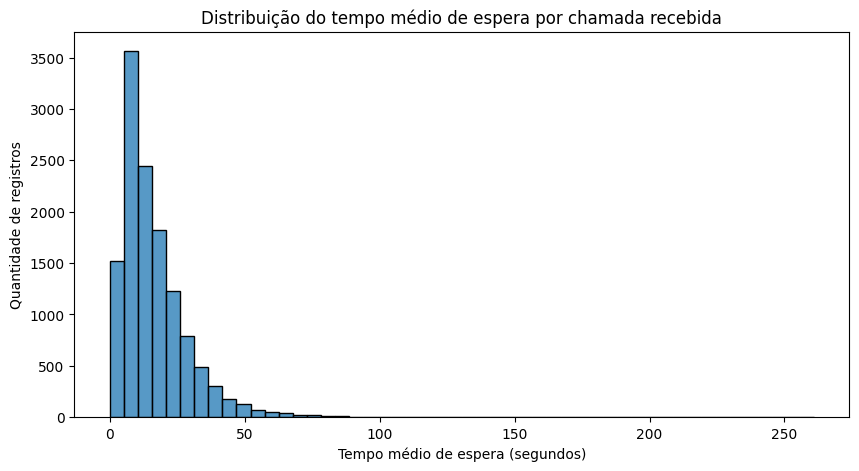

In [24]:
# Visualização da distribuição do tempo médio de espera nas chamadas recebidas
plt.figure(figsize=(10, 5))

sns.histplot(
    incoming_calls['avg_waiting_time'],
    bins=50
)

plt.title('Distribuição do tempo médio de espera por chamada recebida')
plt.xlabel('Tempo médio de espera (segundos)')
plt.ylabel('Quantidade de registros')

plt.show()

In [25]:
# Identificação de valores extremos no tempo médio de espera pelo método do IQR
q1 = incoming_calls['avg_waiting_time'].quantile(0.25)
q3 = incoming_calls['avg_waiting_time'].quantile(0.75)

iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr

outliers_waiting = incoming_calls[
    incoming_calls['avg_waiting_time'] > upper_limit
]

print('Q1:', round(q1, 2))
print('Q3:', round(q3, 2))
print('Limite superior pelo IQR:', round(upper_limit, 2))
print('Quantidade de valores acima do limite:', len(outliers_waiting))
print(
    'Percentual de valores acima do limite:',
    round(len(outliers_waiting) / len(incoming_calls) * 100, 2),
    '%'
)

Q1: 7.67
Q3: 21.33
Limite superior pelo IQR: 41.83
Quantidade de valores acima do limite: 561
Percentual de valores acima do limite: 4.41 %


In [26]:
# Agregação das chamadas recebidas por operador
incoming_operator = (
    incoming_calls
    .groupby(['user_id', 'operator_id'])
    .agg(
        total_in_calls=('calls_count', 'sum'),
        total_waiting_time=('waiting_time', 'sum')
    )
    .reset_index()
)

# Soma das chamadas recebidas que foram perdidas
missed_in_operator = (
    incoming_calls[incoming_calls['is_missed_call'] == True]
    .groupby(['user_id', 'operator_id'])['calls_count']
    .sum()
    .reset_index(name='missed_in_calls')
)

# Junção das informações e cálculo dos principais indicadores de entrada
incoming_operator = incoming_operator.merge(
    missed_in_operator,
    on=['user_id', 'operator_id'],
    how='left'
)

incoming_operator['missed_in_calls'] = incoming_operator['missed_in_calls'].fillna(0)

incoming_operator['missed_rate_%'] = (
    incoming_operator['missed_in_calls']
    / incoming_operator['total_in_calls'] * 100
)

incoming_operator['avg_waiting_time'] = (
    incoming_operator['total_waiting_time']
    / incoming_operator['total_in_calls']
)

display(incoming_operator.head())

,user_id,operator_id,total_in_calls,total_waiting_time,missed_in_calls,missed_rate_%,avg_waiting_time
0,166377,880020,7,54,0.0,0.0,7.714286
1,166377,880022,8,112,0.0,0.0,14.000000
2,166377,880026,24,143,0.0,0.0,5.958333
3,166377,880028,63,343,0.0,0.0,5.444444
4,166391,882476,3,95,0.0,0.0,31.666667


In [27]:
# Resumo estatístico dos indicadores de chamadas recebidas por operador
display(
    incoming_operator[
        [
            'total_in_calls',
            'missed_in_calls',
            'missed_rate_%',
            'avg_waiting_time'
        ]
    ].describe()
)

,total_in_calls,missed_in_calls,missed_rate_%,avg_waiting_time
count,754.000000,754.000000,754.000000,754.000000
mean,124.405836,1.228117,1.757385,17.491612
std,356.450649,3.797106,6.532449,12.171988
min,1.000000,0.000000,0.000000,0.683673
25%,4.000000,0.000000,0.000000,9.398782
50%,17.000000,0.000000,0.000000,14.430502
75%,78.750000,1.000000,0.674678,21.838889
max,4766.000000,52.000000,100.000000,115.500000


In [28]:
# Agregação do volume de chamadas de saída por operador
outgoing_operator = (
    telecom_operators[telecom_operators['direction'] == 'out']
    .groupby(['user_id', 'operator_id'])
    .agg(
        total_out_calls=('calls_count', 'sum')
    )
    .reset_index()
)

# Resumo estatístico do volume de chamadas de saída
display(outgoing_operator['total_out_calls'].describe())

count      882.000000
mean       689.731293
std       3122.953946
min          1.000000
25%         11.000000
50%         90.000000
75%        597.250000
max      58977.000000
Name: total_out_calls, dtype: float64

In [29]:
# Combinação dos indicadores de chamadas de entrada e saída por operador
operator_metrics = incoming_operator.merge(
    outgoing_operator,
    on=['user_id', 'operator_id'],
    how='outer'
)

# Identifica quais operadores possuem atividade de entrada e/ou saída
operator_metrics['has_incoming'] = operator_metrics['total_in_calls'].notna()
operator_metrics['has_outgoing'] = operator_metrics['total_out_calls'].notna()

# Preenche com zero apenas os volumes inexistentes
operator_metrics['total_in_calls'] = operator_metrics['total_in_calls'].fillna(0)
operator_metrics['total_out_calls'] = operator_metrics['total_out_calls'].fillna(0)
operator_metrics['missed_in_calls'] = operator_metrics['missed_in_calls'].fillna(0)

print('Quantidade total de operadores:', len(operator_metrics))

print('\nOperadores com chamadas de entrada:')
print(operator_metrics['has_incoming'].sum())

print('\nOperadores com chamadas de saída:')
print(operator_metrics['has_outgoing'].sum())

display(operator_metrics.head())

Quantidade total de operadores: 1092

Operadores com chamadas de entrada:
754

Operadores com chamadas de saída:
882


,user_id,operator_id,total_in_calls,total_waiting_time,missed_in_calls,missed_rate_%,avg_waiting_time,total_out_calls,has_incoming,has_outgoing
0,166377,880020,7.0,54.0,0.0,0.0,7.714286,38.0,True,True
1,166377,880022,8.0,112.0,0.0,0.0,14.000000,189.0,True,True
2,166377,880026,24.0,143.0,0.0,0.0,5.958333,2208.0,True,True
3,166377,880028,63.0,343.0,0.0,0.0,5.444444,2497.0,True,True
4,166391,882476,3.0,95.0,0.0,0.0,31.666667,0.0,True,False


In [30]:
# Classificação dos operadores de acordo com o tipo de atividade realizada
operator_activity = pd.crosstab(
    operator_metrics['has_incoming'],
    operator_metrics['has_outgoing']
)

display(operator_activity)


has_outgoing,False,True
has_incoming,,
False,0,338
True,210,544


In [31]:
# Classificação do perfil de atividade de cada operador
def classify_activity(row):
    if row['has_incoming'] and row['has_outgoing']:
        return 'entrada e saída'
    elif row['has_incoming']:
        return 'somente entrada'
    else:
        return 'somente saída'

operator_metrics['activity_type'] = operator_metrics.apply(
    classify_activity,
    axis=1
)

# Verificação da quantidade de operadores por tipo de atividade
print(operator_metrics['activity_type'].value_counts())

entrada e saída    544
somente saída      338
somente entrada    210
Name: activity_type, dtype: int64


In [32]:
# Adiciona o plano tarifário de cada cliente à tabela de métricas dos operadores
operator_metrics = operator_metrics.merge(
    clients[['user_id', 'tariff_plan']],
    on='user_id',
    how='left'
)

# Verificação da distribuição dos operadores por plano tarifário
print(operator_metrics['tariff_plan'].value_counts())

B    395
C    387
A    310
Name: tariff_plan, dtype: int64


In [33]:
# Análise do volume de chamadas recebidas perdidas por tipo: interna ou externa
incoming_internal = incoming_calls.copy()

# Identifica explicitamente os poucos registros sem informação sobre internal
incoming_internal['internal_type'] = (
    incoming_internal['internal']
    .fillna('Ausente')
    .replace({
        True: 'Interna',
        False: 'Externa'
    })
)

# Soma o volume real de chamadas recebidas por tipo e status
incoming_internal_summary = (
    incoming_internal
    .groupby(['internal_type', 'is_missed_call'])['calls_count']
    .sum()
    .unstack(fill_value=0)
)

display(incoming_internal_summary)

is_missed_call,False,True
internal_type,,
Ausente,59,1
Externa,92150,901
Interna,667,24


In [34]:
# Cálculo da taxa de chamadas recebidas perdidas por tipo
incoming_internal_summary['total_calls'] = (
    incoming_internal_summary[False]
    + incoming_internal_summary[True]
)

incoming_internal_summary['missed_rate_%'] = (
    incoming_internal_summary[True]
    / incoming_internal_summary['total_calls']
    * 100
).round(2)

display(incoming_internal_summary)

is_missed_call,False,True,total_calls,missed_rate_%
internal_type,,,,
Ausente,59,1,60,1.67
Externa,92150,901,93051,0.97
Interna,667,24,691,3.47


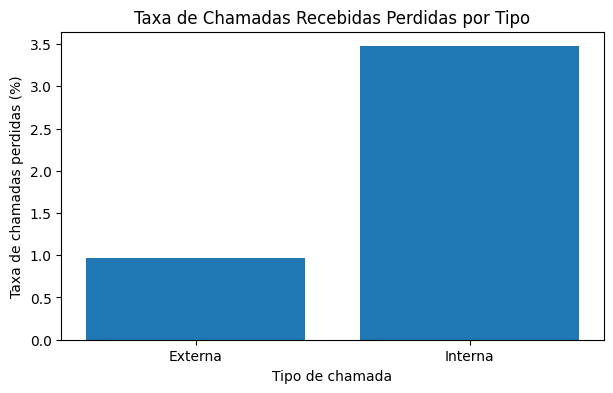

In [35]:
# Taxa de chamadas recebidas perdidas por tipo de chamada

incoming_calls = telecom_operators[
    telecom_operators['direction'] == 'in'
].copy()

# Total de chamadas recebidas por tipo
total_by_internal = (
    incoming_calls
    .groupby('internal', as_index=False)
    .agg(total_calls=('calls_count', 'sum'))
)

# Total de chamadas perdidas por tipo
missed_by_internal = (
    incoming_calls[incoming_calls['is_missed_call'] == True]
    .groupby('internal', as_index=False)
    .agg(missed_calls=('calls_count', 'sum'))
)

# Junta os resultados
missed_rate_internal = total_by_internal.merge(
    missed_by_internal,
    on='internal',
    how='left'
)

missed_rate_internal['missed_calls'] = (
    missed_rate_internal['missed_calls'].fillna(0)
)

# Calcula a taxa percentual
missed_rate_internal['missed_rate'] = (
    missed_rate_internal['missed_calls']
    / missed_rate_internal['total_calls']
    * 100
)

# Nomes mais claros para o gráfico
missed_rate_internal['tipo_chamada'] = (
    missed_rate_internal['internal']
    .map({
        True: 'Interna',
        False: 'Externa'
    })
)

# Gráfico
plt.figure(figsize=(7, 4))

plt.bar(
    missed_rate_internal['tipo_chamada'],
    missed_rate_internal['missed_rate']
)

plt.title('Taxa de Chamadas Recebidas Perdidas por Tipo')
plt.xlabel('Tipo de chamada')
plt.ylabel('Taxa de chamadas perdidas (%)')

plt.show()

### Análise visual

O gráfico permite comparar a proporção de chamadas recebidas perdidas entre chamadas internas e externas.

A diferença observada será posteriormente avaliada por meio de um teste estatístico, permitindo verificar se existe associação significativa entre o tipo da chamada e a ocorrência de chamadas perdidas.

In [36]:
# Comparação do tempo médio de espera por tipo de chamada recebida
waiting_by_type = (
    incoming_internal
    .groupby('internal_type')['avg_waiting_time']
    .agg(['count', 'mean', 'median', 'std'])
    .round(2)
)

display(waiting_by_type)


,count,mean,median,std
internal_type,,,,
Ausente,55,16.21,10.0,14.70
Externa,12292,16.56,13.0,13.59
Interna,386,13.87,11.0,12.07


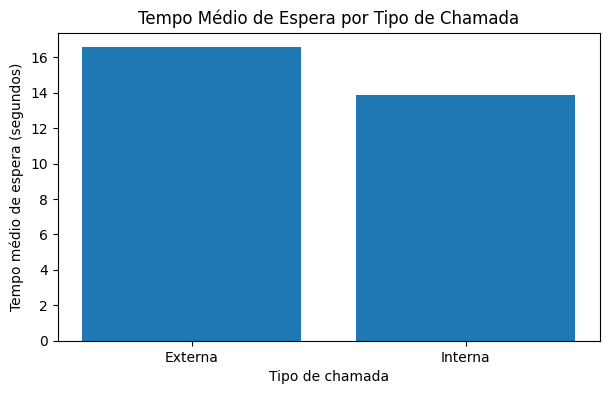

In [37]:
# Comparação visual do tempo médio de espera
# entre chamadas recebidas internas e externas

waiting_plot = waiting_by_type.loc[
    ['Externa', 'Interna'],
    'mean'
]

plt.figure(figsize=(7, 4))

plt.bar(
    waiting_plot.index,
    waiting_plot.values
)

plt.title('Tempo Médio de Espera por Tipo de Chamada')
plt.xlabel('Tipo de chamada')
plt.ylabel('Tempo médio de espera (segundos)')

plt.show()

### Análise visual

O gráfico mostra que as chamadas externas apresentam um tempo médio de espera superior ao observado nas chamadas internas.

Essa diferença será posteriormente avaliada por meio de um teste estatístico para verificar se ela é estatisticamente significativa.

In [38]:
# Comparação dos principais indicadores de chamadas recebidas entre os planos tarifários
plan_summary = (
    incoming_calls
    .groupby('tariff_plan')
    .agg(
        total_calls=('calls_count', 'sum'),
        total_waiting_time=('waiting_time', 'sum')
    )
)

# Soma das chamadas recebidas perdidas em cada plano
missed_by_plan = (
    incoming_calls[incoming_calls['is_missed_call']]
    .groupby('tariff_plan')['calls_count']
    .sum()
)

plan_summary['missed_calls'] = missed_by_plan

# Cálculo da taxa de perda e do tempo médio de espera por chamada
plan_summary['missed_rate_%'] = (
    plan_summary['missed_calls'] / plan_summary['total_calls'] * 100
)

plan_summary['avg_waiting_time'] = (
    plan_summary['total_waiting_time'] / plan_summary['total_calls']
)

display(plan_summary.round(2))

,total_calls,total_waiting_time,missed_calls,missed_rate_%,avg_waiting_time
tariff_plan,,,,,
A,31803,305073,386,1.21,9.59
B,28210,503450,313,1.11,17.85
C,33789,424762,227,0.67,12.57


In [39]:
# Quartis dos indicadores utilizados para avaliar a eficiência dos operadores
print('Taxa de chamadas recebidas perdidas:')
print(
    operator_metrics.loc[
        operator_metrics['has_incoming'],
        'missed_rate_%'
    ].quantile([0.25, 0.50, 0.75, 0.90])
)

print('\nTempo médio de espera nas chamadas recebidas:')
print(
    operator_metrics.loc[
        operator_metrics['has_incoming'],
        'avg_waiting_time'
    ].quantile([0.25, 0.50, 0.75, 0.90])
)

print('\nVolume de chamadas de saída:')
print(
    operator_metrics.loc[
        operator_metrics['has_outgoing'],
        'total_out_calls'
    ].quantile([0.25, 0.50, 0.75, 0.90])
)

Taxa de chamadas recebidas perdidas:
0.25    0.000000
0.50    0.000000
0.75    0.674678
0.90    3.703704
Name: missed_rate_%, dtype: float64

Tempo médio de espera nas chamadas recebidas:
0.25     9.398782
0.50    14.430502
0.75    21.838889
0.90    33.870116
Name: avg_waiting_time, dtype: float64

Volume de chamadas de saída:
0.25      11.00
0.50      90.00
0.75     597.25
0.90    1602.90
Name: total_out_calls, dtype: float64


In [40]:
# Definição dos limites com base nos quartis da distribuição dos operadores
missed_limit = operator_metrics.loc[
    operator_metrics['has_incoming'], 'missed_rate_%'
].quantile(0.75)

waiting_limit = operator_metrics.loc[
    operator_metrics['has_incoming'], 'avg_waiting_time'
].quantile(0.75)

outgoing_limit = operator_metrics.loc[
    operator_metrics['has_outgoing'], 'total_out_calls'
].quantile(0.25)

# Quantidade de operadores que ultrapassam cada limite
high_missed = (
    operator_metrics['has_incoming']
    & (operator_metrics['missed_rate_%'] > missed_limit)
)

high_waiting = (
    operator_metrics['has_incoming']
    & (operator_metrics['avg_waiting_time'] > waiting_limit)
)

low_outgoing = (
    operator_metrics['has_outgoing']
    & (operator_metrics['total_out_calls'] < outgoing_limit)
)

print('Limite para taxa de chamadas perdidas:', round(missed_limit, 2), '%')
print('Operadores acima do limite:', high_missed.sum())

print('\nLimite para tempo médio de espera:', round(waiting_limit, 2), 'segundos')
print('Operadores acima do limite:', high_waiting.sum())

print('\nLimite para baixo volume de saída:', round(outgoing_limit, 2), 'chamadas')
print('Operadores abaixo do limite:', low_outgoing.sum())

Limite para taxa de chamadas perdidas: 0.67 %
Operadores acima do limite: 189

Limite para tempo médio de espera: 21.84 segundos
Operadores acima do limite: 189

Limite para baixo volume de saída: 11.0 chamadas
Operadores abaixo do limite: 214


In [41]:
# Registro dos critérios de possível ineficiência na tabela de operadores
operator_metrics['high_missed'] = high_missed
operator_metrics['high_waiting'] = high_waiting
operator_metrics['low_outgoing'] = low_outgoing

# Soma da quantidade de critérios atendidos por cada operador
operator_metrics['inefficiency_signals'] = (
    operator_metrics[
        ['high_missed', 'high_waiting', 'low_outgoing']
    ]
    .sum(axis=1)
)

# Distribuição dos operadores pela quantidade de sinais de ineficiência
print(
    operator_metrics['inefficiency_signals']
    .value_counts()
    .sort_index()
)


0    594
1    406
2     90
3      2
Name: inefficiency_signals, dtype: int64


In [42]:
# Verificação das combinações de sinais de possível ineficiência
signal_combinations = (
    operator_metrics
    .groupby(['high_missed', 'high_waiting', 'low_outgoing'])
    .size()
    .reset_index(name='operators')
    .sort_values('operators', ascending=False)
)

display(signal_combinations)

,high_missed,high_waiting,low_outgoing,operators
0,False,False,False,594
1,False,False,True,169
4,True,False,False,129
2,False,True,False,108
6,True,True,False,47
3,False,True,True,32
5,True,False,True,11
7,True,True,True,2


In [43]:
# Classificação dos operadores potencialmente ineficientes de acordo com seu perfil de atividade
operator_metrics['is_inefficient'] = False

operator_metrics.loc[
    (operator_metrics['activity_type'] == 'somente entrada')
    & operator_metrics['high_missed']
    & operator_metrics['high_waiting'],
    'is_inefficient'
] = True

operator_metrics.loc[
    (operator_metrics['activity_type'] == 'somente saída')
    & operator_metrics['low_outgoing'],
    'is_inefficient'
] = True

operator_metrics.loc[
    (operator_metrics['activity_type'] == 'entrada e saída')
    & operator_metrics['high_missed']
    & operator_metrics['high_waiting']
    & operator_metrics['low_outgoing'],
    'is_inefficient'
] = True

# Verificação da quantidade de operadores classificados em cada grupo
inefficient_summary = pd.crosstab(
    operator_metrics['activity_type'],
    operator_metrics['is_inefficient']
)

display(inefficient_summary)

print(
    '\nTotal de operadores potencialmente ineficientes:',
    operator_metrics['is_inefficient'].sum()
)

is_inefficient,False,True
activity_type,,
entrada e saída,542,2
somente entrada,198,12
somente saída,237,101



Total de operadores potencialmente ineficientes: 115


### Refinamento do critério de chamadas de saída

A classificação inicial identificou **115 operadores potencialmente ineficientes** utilizando o volume total de chamadas de saída como um dos critérios.

Entretanto, o volume total pode ser influenciado pela quantidade de dias em que cada operador esteve ativo. Um operador com poucos dias de atividade pode apresentar um volume total baixo sem necessariamente indicar baixa eficiência.

Para tornar a comparação mais justa, o indicador de chamadas de saída foi refinado para considerar a **média de chamadas de saída por dia ativo**.

A classificação apresentada a seguir utiliza esse novo indicador e será considerada a **classificação final de ineficiência** do projeto.

In [44]:
# Calcula a quantidade de chamadas de saída e os dias de atividade de cada operador
outgoing_daily = (
    telecom_operators[telecom_operators['direction'] == 'out']
    .groupby(['user_id', 'operator_id'])
    .agg(
        total_out_calls=('calls_count', 'sum'),
        active_days=('date', 'nunique')
    )
    .reset_index()
)

# Calcula a média de chamadas de saída por dia ativo
outgoing_daily['avg_out_calls_day'] = (
    outgoing_daily['total_out_calls']
    / outgoing_daily['active_days']
)

# Resumo estatístico do novo indicador
display(outgoing_daily['avg_out_calls_day'].describe())

count    882.000000
mean      29.390987
std       67.048008
min        1.000000
25%        2.666667
50%        6.586128
75%       29.000000
max      816.791667
Name: avg_out_calls_day, dtype: float64

In [45]:
# Adiciona à tabela principal a média de chamadas de saída por dia ativo
operator_metrics = operator_metrics.merge(
    outgoing_daily[
        ['user_id', 'operator_id', 'active_days', 'avg_out_calls_day']
    ],
    on=['user_id', 'operator_id'],
    how='left'
)

# Define como baixo desempenho de saída os operadores abaixo do 1º quartil
outgoing_daily_limit = outgoing_daily['avg_out_calls_day'].quantile(0.25)

operator_metrics['low_outgoing_daily'] = (
    operator_metrics['has_outgoing']
    & (operator_metrics['avg_out_calls_day'] < outgoing_daily_limit)
)

print(
    'Limite de baixo volume médio diário:',
    round(outgoing_daily_limit, 2),
    'chamadas por dia'
)

print(
    'Operadores abaixo do limite:',
    operator_metrics['low_outgoing_daily'].sum()
)

Limite de baixo volume médio diário: 2.67 chamadas por dia
Operadores abaixo do limite: 217


In [46]:
# Reclassificação dos operadores usando a média diária de chamadas de saída
operator_metrics['is_inefficient'] = False

# Operadores que atuam somente com chamadas de entrada
operator_metrics.loc[
    (operator_metrics['activity_type'] == 'somente entrada')
    & operator_metrics['high_missed']
    & operator_metrics['high_waiting'],
    'is_inefficient'
] = True

# Operadores que atuam somente com chamadas de saída
operator_metrics.loc[
    (operator_metrics['activity_type'] == 'somente saída')
    & operator_metrics['low_outgoing_daily'],
    'is_inefficient'
] = True

# Operadores que atuam com entrada e saída
operator_metrics.loc[
    (operator_metrics['activity_type'] == 'entrada e saída')
    & operator_metrics['high_missed']
    & operator_metrics['high_waiting']
    & operator_metrics['low_outgoing_daily'],
    'is_inefficient'
] = True

# Verificação da nova classificação
inefficient_summary = pd.crosstab(
    operator_metrics['activity_type'],
    operator_metrics['is_inefficient']
)

display(inefficient_summary)

print(
    '\nTotal de operadores potencialmente ineficientes:',
    operator_metrics['is_inefficient'].sum()
)

is_inefficient,False,True
activity_type,,
entrada e saída,538,6
somente entrada,198,12
somente saída,257,81



Total de operadores potencialmente ineficientes: 99


### Relação entre os indicadores de ineficiência

Além da análise individual de cada indicador, foi verificado como os principais sinais de possível ineficiência aparecem em conjunto entre os operadores.

Nesta etapa são considerados os critérios finais utilizados no projeto:

- taxa elevada de chamadas recebidas perdidas;
- tempo médio de espera elevado;
- baixo volume médio diário de chamadas de saída.

Essa análise permite observar se diferentes sinais de ineficiência ocorrem simultaneamente e reforça a utilização conjunta dos indicadores na classificação dos operadores.

In [63]:
# Verificação das combinações dos indicadores finais de ineficiência
final_signal_combinations = (
    operator_metrics
    .groupby([
        'high_missed',
        'high_waiting',
        'low_outgoing_daily'
    ])
    .size()
    .reset_index(name='operators')
    .sort_values('operators', ascending=False)
)

display(final_signal_combinations)

,high_missed,high_waiting,low_outgoing_daily,operators
0,False,False,False,610
1,False,False,True,153
4,True,False,False,119
2,False,True,False,103
6,True,True,False,43
3,False,True,True,37
5,True,False,True,21
7,True,True,True,6


### Conclusão — Relação entre os indicadores

A análise conjunta dos indicadores mostra que **610 operadores não apresentaram nenhum dos três sinais de possível ineficiência**.

Também foram identificados operadores que apresentaram apenas um dos sinais analisados:

- **153** apresentaram somente baixo volume médio diário de chamadas de saída;
- **119** apresentaram somente taxa elevada de chamadas perdidas;
- **103** apresentaram somente tempo médio de espera elevado.

Além disso, **107 operadores apresentaram dois ou mais sinais simultaneamente**, sendo:

- **43** com taxa elevada de chamadas perdidas e tempo de espera elevado;
- **37** com tempo de espera elevado e baixo volume diário de chamadas de saída;
- **21** com taxa elevada de chamadas perdidas e baixo volume diário de chamadas de saída;
- **6** apresentaram os três sinais simultaneamente.

Esses resultados mostram que os indicadores podem ocorrer tanto de forma isolada quanto combinada. Por esse motivo, a classificação final não considera apenas a quantidade de sinais apresentados, mas também o **tipo de atividade de cada operador**, evitando penalizar operadores por métricas que não fazem parte de sua função.

Assim, a análise conjunta dos indicadores complementa a classificação final dos **99 operadores potencialmente ineficientes** identificados no projeto.

In [47]:
# Comparação dos principais indicadores entre operadores classificados
# como eficientes e potencialmente ineficientes
efficiency_comparison = (
    operator_metrics
    .groupby('is_inefficient')
    .agg(
        operadores=('operator_id', 'count'),
        taxa_media_perdidas=('missed_rate_%', 'mean'),
        espera_media=('avg_waiting_time', 'mean'),
        chamadas_saida_dia=('avg_out_calls_day', 'mean')
    )
    .round(2)
)

display(efficiency_comparison)

,operadores,taxa_media_perdidas,espera_media,chamadas_saida_dia
is_inefficient,,,,
False,993,1.59,17.17,32.43
True,99,8.64,30.58,1.58


## Conclusão da etapa 3

A análise exploratória mostrou que a maior parte da atividade dos operadores está concentrada em chamadas de saída. Nas chamadas recebidas, a taxa geral de perdas foi baixa, embora chamadas internas tenham apresentado proporção de perda superior às externas.

O tempo de espera apresentou distribuição assimétrica, com alguns valores elevados. Esses registros foram mantidos, pois podem representar situações reais de baixa eficiência e são relevantes para o objetivo do projeto.

Foram identificados **1.092 operadores**, distribuídos entre atividades somente de entrada, somente de saída ou ambas. Para evitar comparações injustas, os indicadores foram avaliados de acordo com o tipo de atividade de cada operador.

Os limites para identificação de possíveis sinais de ineficiência foram definidos com base nos quartis das próprias distribuições:

- taxa elevada de chamadas recebidas perdidas;
- tempo médio de espera elevado;
- baixo número médio de chamadas de saída por dia ativo.

Com esses critérios, **99 operadores foram classificados como potencialmente ineficientes**.

A comparação entre os grupos mostrou que os operadores classificados como ineficientes possuem maior taxa de chamadas perdidas, maior tempo médio de espera e menor volume diário de chamadas de saída.

A próxima etapa será a realização de **testes estatísticos** para verificar se as diferenças observadas são estatisticamente significativas.

## Testes estatísticos

### Hipótese 1 — Chamadas recebidas perdidas: internas x externas

Nesta análise, será verificado se existe associação entre o tipo da chamada recebida e a ocorrência de chamadas perdidas.

- **H0 — Hipótese nula:** o tipo da chamada recebida, interna ou externa, é independente da ocorrência de chamadas perdidas.
- **H1 — Hipótese alternativa:** existe associação entre o tipo da chamada recebida e a ocorrência de chamadas perdidas.

Será utilizado o **teste qui-quadrado de independência**, com nível de significância de **5%**.

In [48]:

# Montagem da tabela de contingência para chamadas recebidas internas e externas
contingency_table = pd.DataFrame(
    {
        'Atendida': [
            incoming_internal_summary.at['Externa', False],
            incoming_internal_summary.at['Interna', False]
        ],
        'Perdida': [
            incoming_internal_summary.at['Externa', True],
            incoming_internal_summary.at['Interna', True]
        ]
    },
    index=['Externa', 'Interna']
)

# Teste qui-quadrado de independência
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

alpha = 0.05

print('Tabela de contingência:')
display(contingency_table)

print('Estatística qui-quadrado:', round(chi2, 4))
print('p-valor:', p_value)

if p_value < alpha:
    print('Resultado: rejeitamos a hipótese nula.')
else:
    print('Resultado: não rejeitamos a hipótese nula.')

Tabela de contingência:


,Atendida,Perdida
Externa,92150,901
Interna,667,24


Estatística qui-quadrado: 41.5248
p-valor: 1.1638722398975847e-10
Resultado: rejeitamos a hipótese nula.


### Conclusão — Hipótese 1

O teste qui-quadrado apresentou **p-valor de aproximadamente 1,16 × 10⁻¹⁰**, inferior ao nível de significância de 5%.

Portanto, **rejeitamos a hipótese nula**, indicando que existe associação estatisticamente significativa entre o tipo da chamada recebida e a ocorrência de chamadas perdidas.

As chamadas internas apresentaram taxa de perda de **3,47%**, enquanto as externas apresentaram **0,97%**. Apesar da diferença estatística, é importante considerar que o volume de chamadas internas é muito menor que o de chamadas externas.

### Hipótese 2 — Tempo médio de espera: chamadas internas x externas

Nesta análise, será verificado se o tempo médio de espera apresenta diferença significativa entre chamadas recebidas internas e externas.

- **H0 — Hipótese nula:** não existe diferença estatisticamente significativa na distribuição do tempo médio de espera entre chamadas internas e externas.
- **H1 — Hipótese alternativa:** existe diferença estatisticamente significativa na distribuição do tempo médio de espera entre chamadas internas e externas.

Primeiro será verificada a normalidade das distribuições. Caso os dados não apresentem distribuição normal, será utilizado o **teste não paramétrico de Mann-Whitney U**, com nível de significância de **5%**.

In [49]:
# Prepara os grupos de tempo de espera para verificar a normalidade
waiting_external = incoming_internal[
    incoming_internal['internal_type'] == 'Externa'
]['avg_waiting_time']

waiting_internal = incoming_internal[
    incoming_internal['internal_type'] == 'Interna'
]['avg_waiting_time']

# Limita a amostra para o teste de Shapiro-Wilk
sample_external = waiting_external.sample(
    n=min(5000, len(waiting_external)),
    random_state=42
)

sample_internal = waiting_internal.sample(
    n=min(5000, len(waiting_internal)),
    random_state=42
)

# Teste de normalidade
shapiro_external = stats.shapiro(sample_external)
shapiro_internal = stats.shapiro(sample_internal)

print('Chamadas externas - p-valor:', shapiro_external.pvalue)
print('Chamadas internas - p-valor:', shapiro_internal.pvalue)

Chamadas externas - p-valor: 0.0
Chamadas internas - p-valor: 1.2127204487760441e-20


In [50]:
# Comparação do tempo médio de espera entre chamadas internas e externas
# utilizando o teste não paramétrico de Mann-Whitney U
u_stat, p_value = stats.mannwhitneyu(
    waiting_external,
    waiting_internal,
    alternative='two-sided'
)

alpha = 0.05

print('Estatística U:', round(u_stat, 2))
print('p-valor:', p_value)

if p_value < alpha:
    print('Resultado: rejeitamos a hipótese nula.')
else:
    print('Resultado: não rejeitamos a hipótese nula.')

Estatística U: 2740889.0
p-valor: 1.9363296405479453e-07
Resultado: rejeitamos a hipótese nula.


### Conclusão — Hipótese 2

O teste de normalidade indicou que as distribuições do tempo médio de espera não seguem uma distribuição normal. Por esse motivo, foi utilizado o teste não paramétrico de Mann-Whitney U.

O teste apresentou **p-valor de aproximadamente 1,94 × 10⁻⁷**, inferior ao nível de significância de 5%.

Portanto, **rejeitamos a hipótese nula**, indicando que existe diferença estatisticamente significativa na distribuição do tempo médio de espera entre chamadas internas e externas.

Na análise descritiva, as chamadas externas apresentaram tempo médio de espera superior ao das chamadas internas.

### Hipótese 3 — Volume de chamadas de saída por perfil de atividade

Nesta análise, será verificado se o volume médio diário de chamadas de saída apresenta diferença significativa entre operadores que realizam chamadas de entrada e saída e operadores que realizam somente chamadas de saída.

- **H0 — Hipótese nula:** não existe diferença estatisticamente significativa na distribuição do volume médio diário de chamadas de saída entre os dois perfis de atividade.
- **H1 — Hipótese alternativa:** existe diferença estatisticamente significativa na distribuição do volume médio diário de chamadas de saída entre os dois perfis de atividade.

Primeiro será verificada a normalidade das distribuições. Caso os dados não apresentem distribuição normal, será utilizado o **teste não paramétrico de Mann-Whitney U**, com nível de significância de **5%**.

In [51]:
# Comparação descritiva da média diária de chamadas de saída
# entre os diferentes perfis de operadores
outgoing_profile = operator_metrics[
    operator_metrics['has_outgoing']
].copy()

outgoing_profile_summary = (
    outgoing_profile
    .groupby('activity_type')['avg_out_calls_day']
    .agg(['count', 'mean', 'median', 'std'])
    .round(2)
)

display(outgoing_profile_summary)

,count,mean,median,std
activity_type,,,,
entrada e saída,544,18.54,5.63,56.49
somente saída,338,46.86,9.85,78.19


In [52]:
# Separa os operadores de acordo com o perfil de atividade
out_both = outgoing_profile[
    outgoing_profile['activity_type'] == 'entrada e saída'
]['avg_out_calls_day']

out_only = outgoing_profile[
    outgoing_profile['activity_type'] == 'somente saída'
]['avg_out_calls_day']

# Teste de normalidade das distribuições
shapiro_both = stats.shapiro(out_both)
shapiro_only = stats.shapiro(out_only)

print('Entrada e saída - p-valor:', shapiro_both.pvalue)
print('Somente saída - p-valor:', shapiro_only.pvalue)

Entrada e saída - p-valor: 2.7059073346112218e-42
Somente saída - p-valor: 7.810606963532491e-28


In [53]:
# Comparação da média diária de chamadas de saída entre os dois perfis
# utilizando o teste não paramétrico de Mann-Whitney U
u_stat, p_value = stats.mannwhitneyu(
    out_both,
    out_only,
    alternative='two-sided'
)

alpha = 0.05

print('Estatística U:', round(u_stat, 2))
print('p-valor:', p_value)

if p_value < alpha:
    print('Resultado: rejeitamos a hipótese nula.')
else:
    print('Resultado: não rejeitamos a hipótese nula.')

Estatística U: 75047.5
p-valor: 4.3617062742216e-06
Resultado: rejeitamos a hipótese nula.


### Conclusão — Hipótese 3

As distribuições da média diária de chamadas de saída não apresentaram normalidade, portanto foi utilizado o teste não paramétrico de Mann-Whitney U.

O teste apresentou **p-valor de aproximadamente 4,36 × 10⁻⁶**, inferior ao nível de significância de 5%.

Assim, **rejeitamos a hipótese nula**, indicando que existe diferença estatisticamente significativa na distribuição do volume médio diário de chamadas de saída entre operadores que atuam somente com saída e operadores que realizam chamadas de entrada e saída.

Na análise descritiva, os operadores de somente saída apresentaram maior volume diário de chamadas, o que mostra que o tipo de atividade deve ser considerado na avaliação de desempenho.

## Conclusão da etapa 4

Os testes estatísticos confirmaram diferenças relevantes entre os grupos analisados.

- Foi identificada associação estatisticamente significativa entre o tipo da chamada recebida e a ocorrência de chamadas perdidas.
- O tempo médio de espera apresentou diferença estatisticamente significativa entre chamadas internas e externas.
- O volume médio diário de chamadas de saída também apresentou diferença significativa entre operadores que atuam somente com saída e aqueles que dividem sua atividade entre entrada e saída.

Como as distribuições analisadas não apresentaram normalidade, foram utilizados testes não paramétricos quando necessário.

Os resultados reforçam que a avaliação de eficiência deve considerar diferentes indicadores e também o perfil de atividade de cada operador, evitando comparações inadequadas entre funções distintas.

In [54]:
# Criação da tabela final com os operadores classificados como potencialmente ineficientes
inefficient_operators = operator_metrics[
    operator_metrics['is_inefficient']
].copy()

# Seleção dos principais indicadores para análise final
inefficient_operators = inefficient_operators[
    [
        'user_id',
        'operator_id',
        'activity_type',
        'tariff_plan',
        'missed_rate_%',
        'avg_waiting_time',
        'avg_out_calls_day'
    ]
]

print('Quantidade de operadores potencialmente ineficientes:')
print(len(inefficient_operators))

display(inefficient_operators.head())

Quantidade de operadores potencialmente ineficientes:
99


,user_id,operator_id,activity_type,tariff_plan,missed_rate_%,avg_waiting_time,avg_out_calls_day
33,166482,934076,somente entrada,C,9.090909,28.272727,NaN
83,166669,888406,entrada e saída,C,11.111111,28.333333,1.0
123,166782,894120,somente entrada,C,5.555556,23.777778,NaN
158,166879,896538,somente entrada,A,7.142857,47.500000,NaN
185,166916,906410,entrada e saída,A,3.017241,26.012931,1.9


In [55]:
# Distribuição dos operadores potencialmente ineficientes por perfil de atividade
inefficient_by_activity = (
    inefficient_operators['activity_type']
    .value_counts()
)

display(inefficient_by_activity)

somente saída      81
somente entrada    12
entrada e saída     6
Name: activity_type, dtype: int64

In [56]:
# Distribuição dos operadores potencialmente ineficientes por plano tarifário
inefficient_by_plan = (
    inefficient_operators['tariff_plan']
    .value_counts()
)

display(inefficient_by_plan)

C    40
B    35
A    24
Name: tariff_plan, dtype: int64

In [57]:
# Comparação proporcional de operadores ineficientes por plano tarifário
plan_efficiency = (
    operator_metrics
    .groupby('tariff_plan')
    .agg(
        total_operators=('operator_id', 'count'),
        inefficient_operators=('is_inefficient', 'sum')
    )
)

plan_efficiency['inefficient_rate_%'] = (
    plan_efficiency['inefficient_operators']
    / plan_efficiency['total_operators']
    * 100
).round(2)

display(plan_efficiency)

,total_operators,inefficient_operators,inefficient_rate_%
tariff_plan,,,
A,310,24,7.74
B,395,35,8.86
C,387,40,10.34


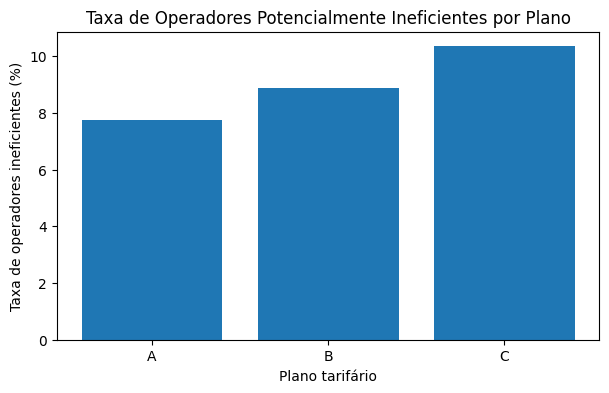

In [62]:
# Comparação visual da taxa de operadores potencialmente ineficientes
# entre os planos tarifários

plt.figure(figsize=(7, 4))

plt.bar(
    plan_efficiency.index,
    plan_efficiency['inefficient_rate_%']
)

plt.title('Taxa de Operadores Potencialmente Ineficientes por Plano')
plt.xlabel('Plano tarifário')
plt.ylabel('Taxa de operadores ineficientes (%)')

plt.show()

### Análise visual

O gráfico mostra que o **plano C apresenta a maior proporção de operadores potencialmente ineficientes**, com **10,34%**, seguido pelo plano B, com **8,86%**, e pelo plano A, com **7,74%**.

Embora as diferenças entre os planos não sejam muito elevadas, o resultado sugere que os clientes do plano C merecem atenção adicional no acompanhamento dos indicadores de desempenho.

In [58]:
# Identificação dos clientes que possuem operadores potencialmente ineficientes
clients_with_inefficient = (
    inefficient_operators['user_id']
    .nunique()
)

total_clients_analyzed = operator_metrics['user_id'].nunique()

print('Clientes com pelo menos um operador ineficiente:',
      clients_with_inefficient)

print('Total de clientes analisados:',
      total_clients_analyzed)

print(
    'Percentual de clientes afetados:',
    round(clients_with_inefficient / total_clients_analyzed * 100, 2),
    '%'
)

Clientes com pelo menos um operador ineficiente: 55
Total de clientes analisados: 290
Percentual de clientes afetados: 18.97 %


In [59]:
# Quantidade de operadores potencialmente ineficientes por cliente
inefficient_by_client = (
    inefficient_operators
    .groupby('user_id')['operator_id']
    .nunique()
    .sort_values(ascending=False)
)

print('Resumo da quantidade de operadores ineficientes por cliente:')
print(inefficient_by_client.describe())

print('\nClientes com maior quantidade de operadores ineficientes:')
display(inefficient_by_client.head(10))

Resumo da quantidade de operadores ineficientes por cliente:
count    55.000000
mean      1.800000
std       1.603237
min       1.000000
25%       1.000000
50%       1.000000
75%       2.000000
max       7.000000
Name: operator_id, dtype: float64

Clientes com maior quantidade de operadores ineficientes:


user_id
166520    7
168187    7
168252    6
166939    5
168073    5
167580    5
168336    4
167989    3
167497    3
166916    3
Name: operator_id, dtype: int64

## Conclusão da etapa 5

Foram identificados **99 operadores potencialmente ineficientes** entre os 1.092 operadores analisados.

A maior parte dos casos está concentrada em operadores que realizam somente chamadas de saída. Entre os planos tarifários, o plano C apresentou a maior proporção de operadores classificados como ineficientes, com **10,34%**, seguido pelos planos B e A.

Ao todo, **55 dos 290 clientes analisados** possuem pelo menos um operador potencialmente ineficiente, representando **18,97%** dos clientes com operadores identificados.

A maioria desses clientes possui apenas um operador classificado como ineficiente, embora alguns concentrem entre 5 e 7 operadores nessa situação. Esses clientes devem receber maior atenção dos supervisores, pois podem indicar problemas de equipe, organização das atividades ou necessidade de treinamento.

Os resultados permitem direcionar o acompanhamento para operadores e clientes específicos, evitando ações generalizadas e tornando a tomada de decisão mais objetiva.

# Conclusão geral e recomendações

A análise permitiu identificar padrões associados à eficiência dos operadores da CallMeMaybe utilizando três indicadores principais: taxa de chamadas recebidas perdidas, tempo médio de espera e volume médio diário de chamadas de saída.

Foram analisados **1.092 operadores**, dos quais **99 foram classificados como potencialmente ineficientes** com base em critérios definidos a partir da distribuição dos próprios dados e considerando o tipo de atividade exercida por cada operador.

Os operadores classificados como potencialmente ineficientes apresentaram, em média:

- maior taxa de chamadas recebidas perdidas;
- maior tempo médio de espera;
- menor volume diário de chamadas de saída.

Os testes estatísticos também mostraram diferenças significativas relacionadas ao tipo das chamadas e ao perfil de atividade dos operadores, reforçando a importância de avaliar o desempenho de acordo com o contexto operacional.

Além disso, **55 dos 290 clientes analisados** possuem pelo menos um operador potencialmente ineficiente. A maioria possui apenas um caso, porém alguns clientes concentram vários operadores com sinais de baixa eficiência.

## Recomendações

Com base nos resultados, recomenda-se que a CallMeMaybe:

1. **Priorize o acompanhamento dos 99 operadores identificados**, utilizando os indicadores encontrados como sinal de alerta e não como decisão automática de desempenho.
2. **Dê atenção especial aos clientes com maior concentração de operadores ineficientes**, pois esses casos podem indicar problemas de treinamento, distribuição de tarefas ou organização da equipe.
3. **Monitore separadamente operadores de entrada, saída e atividade mista**, evitando comparar profissionais com responsabilidades diferentes.
4. **Acompanhe continuamente a taxa de chamadas perdidas e o tempo de espera**, principalmente quando ambos os indicadores estiverem elevados.
5. Para operadores de saída, utilize o **volume médio de chamadas por dia ativo**, em vez do volume total, permitindo comparações mais justas entre operadores com diferentes períodos de atividade.
6. Utilize os resultados como base para um **dashboard de acompanhamento**, permitindo que os supervisores filtrem clientes, operadores, planos tarifários e indicadores de eficiência.

A análise fornece uma base objetiva para que os supervisores direcionem ações de acompanhamento e treinamento para os casos que apresentam maior necessidade de atenção.

In [60]:
# Seleção dos principais indicadores que serão utilizados no dashboard
dashboard_data = operator_metrics[
    [
        'user_id',
        'operator_id',
        'tariff_plan',
        'activity_type',
        'total_in_calls',
        'missed_in_calls',
        'missed_rate_%',
        'avg_waiting_time',
        'total_out_calls',
        'active_days',
        'avg_out_calls_day',
        'is_inefficient'
    ]
].copy()

# Criação de um campo mais intuitivo para exibição no dashboard
dashboard_data['efficiency_status'] = dashboard_data['is_inefficient'].map({
    False: 'Dentro do esperado',
    True: 'Potencialmente ineficiente'
})

# Verificação da tabela preparada
print('Dimensões da tabela para o dashboard:', dashboard_data.shape)

display(dashboard_data.head())

Dimensões da tabela para o dashboard: (1092, 13)


,user_id,operator_id,tariff_plan,activity_type,total_in_calls,missed_in_calls,missed_rate_%,avg_waiting_time,total_out_calls,active_days,avg_out_calls_day,is_inefficient,efficiency_status
0,166377,880020,B,entrada e saída,7.0,0.0,0.0,7.714286,38.0,7.0,5.428571,False,Dentro do esperado
1,166377,880022,B,entrada e saída,8.0,0.0,0.0,14.000000,189.0,36.0,5.250000,False,Dentro do esperado
2,166377,880026,B,entrada e saída,24.0,0.0,0.0,5.958333,2208.0,77.0,28.675325,False,Dentro do esperado
3,166377,880028,B,entrada e saída,63.0,0.0,0.0,5.444444,2497.0,78.0,32.012821,False,Dentro do esperado
4,166391,882476,C,somente entrada,3.0,0.0,0.0,31.666667,0.0,NaN,NaN,False,Dentro do esperado


In [61]:
# Exportação da tabela preparada para utilização no dashboard
dashboard_data.to_csv(
    'dashboard_callmemaybe.csv',
    index=False
)

print('Arquivo dashboard_callmemaybe.csv exportado com sucesso.')

Arquivo dashboard_callmemaybe.csv exportado com sucesso.


## Conclusão da etapa 6

Foi criada uma tabela consolidada com os principais indicadores de desempenho dos **1.092 operadores** analisados.

A base contém informações sobre volume de chamadas de entrada e saída, taxa de chamadas perdidas, tempo médio de espera, média diária de chamadas de saída, perfil de atividade, plano tarifário e classificação de eficiência.

Também foi criado o campo `efficiency_status` para facilitar a interpretação dos resultados no dashboard.

Por fim, os dados foram exportados para o arquivo `dashboard_callmemaybe.csv`, que será utilizado na construção do dashboard.